## objectives

This notebook implements a ResNet50-based deep learning model for classifying waste image into six categories

The model will use transfer learning with a ResNet50 backbone
pretrained on ImageNet.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Project root directory
PROJECT_ROOT = Path.cwd().parent

import tensorflow as tf

print("TF version: ", tf.__version__)

TF version:  2.18.0


## 1. Experiment Configuration

In [2]:
IMG_SIZE = (256,256)
BATCH_SIZE = 16
NUM_CLASSES = 6
SEED = 42

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("Class Names: ", CLASS_NAMES)
print("Number of Classes: ", NUM_CLASSES)
print("Image Size: ", IMG_SIZE)
print("Batch Size: ", BATCH_SIZE)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Class Names:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of Classes:  6
Image Size:  (256, 256)
Batch Size:  16


In [3]:
TRAIN_CSV = "../data/processed/train.csv"
VAL_CSV = "../data/processed/validation.csv"
TEST_CSV = "../data/processed/test.csv"

print(os.path.exists(TRAIN_CSV))
print(os.path.exists(VAL_CSV))
print(os.path.exists(TEST_CSV))

True
True
True


In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Training: (9692, 3)
Validation: (2114, 3)
Test: (2091, 3)


In [5]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['relative_path', 'class', 'label']

Validation columns:
['relative_path', 'class', 'label']

Test columns:
['relative_path', 'class', 'label']


In [6]:
train_df["class"].value_counts()

class
glass        1751
trash        1750
paper        1605
plastic      1598
cardboard    1548
metal        1440
Name: count, dtype: int64

In [7]:
print("Number of classes:", train_df["label"].nunique())

Number of classes: 6


In [8]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64


In [9]:
print("Duplicate training rows:", train_df.duplicated().sum())
print("Duplicate validation rows:", val_df.duplicated().sum())
print("Duplicate test rows:", test_df.duplicated().sum())

Duplicate training rows: 0
Duplicate validation rows: 0
Duplicate test rows: 0


In [10]:
train_df.head()

,relative_path,class,label
0,cardboard/cardboard_00001.jpg,cardboard,0
1,cardboard/cardboard_00007.jpg,cardboard,0
2,cardboard/cardboard_00012.jpg,cardboard,0
3,cardboard/cardboard_00013.jpg,cardboard,0
4,cardboard/cardboard_00016.jpg,cardboard,0


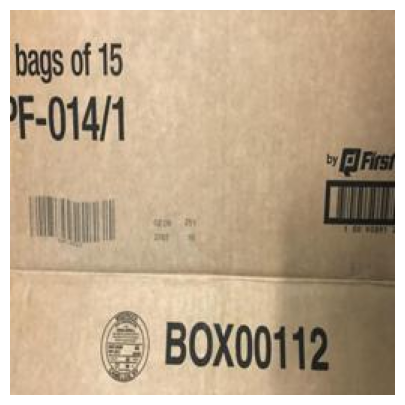

Image size: (256, 256)
Image mode: RGB


In [11]:
image = Image.open("../data/raw/Garbage_Dataset_Classification/images/cardboard/cardboard_00001.jpg")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Image size:", image.size)
print("Image mode:", image.mode)

## 2. ResNet50 Data Preprocessing

In [12]:
from tensorflow.keras.applications.resnet50 import preprocess_input

IMAGE_ROOT = Path("../data/raw/Garbage_Dataset_Classification/images/")
print("Image root:", IMAGE_ROOT)

Image root: ..\data\raw\Garbage_Dataset_Classification\images


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")

In [14]:
def create_dataset(dataframe, training=False):
    paths = dataframe["relative_path"].values
    labels = dataframe["label"].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )
    
    return dataset

In [16]:
def process_image(path, label, training=False):
    
    image_path = tf.strings.join(
        [str(IMAGE_ROOT), "/", path]
    )
    
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(
        image,
        tf.float32
    )
    
    if training:
        image = data_augmentation(image, training=True)
    
    image = preprocess_input(image)
    
    return image, label

In [17]:
def build_dataset(dataframe, training=False):
    dataset = create_dataset(dataframe, training=training)

    dataset = dataset.map(
        lambda path, label: process_image(path, label, training=training),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_dataset = build_dataset(train_df, training=True)
val_dataset = build_dataset(val_df, training=False)
test_dataset = build_dataset(test_df, training=False)

In [18]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)

Image batch shape: (16, 256, 256, 3)
Label batch shape: (16,)
Image dtype: <dtype: 'float32'>


In [19]:
print(labels.numpy())

[5 1 4 2 3 0 5 3 2 4 2 3 3 5 3 0]


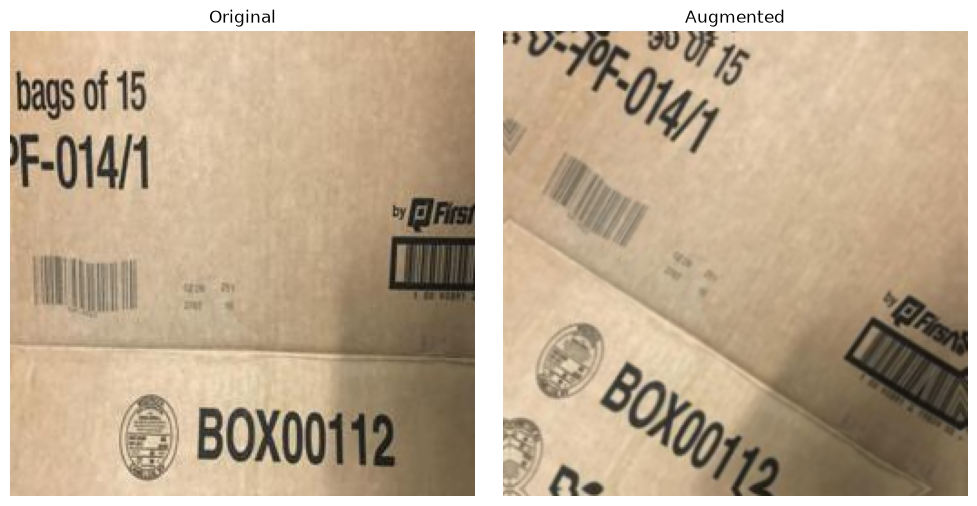

In [20]:
row = train_df.iloc[0]

image_path = IMAGE_ROOT / row["relative_path"]

image = Image.open(image_path).convert("RGB")

image = np.array(image)

image_tensor = tf.convert_to_tensor(
    image,
    dtype=tf.float32
)

augmented = data_augmentation(
    image_tensor,
    training=True
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.astype(np.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(
    tf.clip_by_value(augmented, 0, 255),
    tf.uint8
))
plt.title("Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3. ResNet50 Model Architecture

In [21]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# freeze ResNet weights to avoid retraining them
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.trainable_weights
)
non_trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.non_trainable_weights
)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Trainable parameters: 263046
Non-trainable parameters: 23587712


## 4. Train ResNet50 (Head Only)

In [ ]:
import time

EPOCHS = 15
LEARNING_RATE = 0.001

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print("Model directory:", MODEL_DIR)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_DIR / "resnet50_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ]
)

head_training_time = time.time() - start_time
print(f"\nHead training time: {head_training_time / 60:.2f} minutes")

Model directory: d:\UNI\SE4050-Automatic-Waste-Classification\models
Epoch 1/15


c:\Users\CVR\miniconda3\envs\waste-dl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.7783 - loss: 0.6301
Epoch 1: val_loss improved from None to 0.37169, saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_best.keras

Epoch 1: finished saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_best.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 505s 827ms/step - accuracy: 0.7783 - loss: 0.6301 - val_accuracy: 0.8657 - val_loss: 0.3717 - learning_rate: 0.0010
Epoch 2/15
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.8542 - loss: 0.4146
Epoch 2: val_loss improved from 0.37169 to 0.28455, saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_best.keras

Epoch 2: finished saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_best.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 705s 1s/step - accuracy: 0.8542 - loss: 0.4146 - val_accuracy: 0.8974 - val_loss: 0.2846 - learning_rate: 0.0010
Epoch 3/15
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - a

## 5. Fine-Tuning ResNet50

In [ ]:
best_model = tf.keras.models.load_model(
    MODEL_DIR / "resnet50_best.keras"
)
print("Best model loaded successfully.")

base_model = best_model.layers[0]

fine_tune_from = int(len(base_model.layers) * 0.80)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_model.trainable_weights
)
non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_model.non_trainable_weights
)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

FINE_TUNE_LR = 1e-5

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_DIR / "resnet50_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

FINE_TUNE_EPOCHS = 10

ft_start_time = time.time()

fine_tune_history = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_checkpoint,
        fine_tune_reduce_lr
    ]
)

ft_training_time = time.time() - ft_start_time
print(f"\nFine-tuning time: {ft_training_time / 60:.2f} minutes")

## 6. Training History Visualization

In [ ]:
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Combine training histories from both phases
head_acc = history.history['accuracy']
head_val_acc = history.history['val_accuracy']
head_loss = history.history['loss']
head_val_loss = history.history['val_loss']

ft_acc = fine_tune_history.history['accuracy']
ft_val_acc = fine_tune_history.history['val_accuracy']
ft_loss = fine_tune_history.history['loss']
ft_val_loss = fine_tune_history.history['val_loss']

total_head = len(head_acc)
total_ft = len(ft_acc)

epochs_head = range(1, total_head + 1)
epochs_ft = range(total_head + 1, total_head + total_ft + 1)

# Plot accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(epochs_head, head_acc, 'b-', label='Training Accuracy')
plt.plot(epochs_head, head_val_acc, color='orange', label='Validation Accuracy')
plt.plot(epochs_ft, ft_acc, 'b-')
plt.plot(epochs_ft, ft_val_acc, color='orange')
plt.axvline(x=total_head + 0.5, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('ResNet50 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'resnet50_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot loss curves
plt.figure(figsize=(10, 6))
plt.plot(epochs_head, head_loss, 'b-', label='Training Loss')
plt.plot(epochs_head, head_val_loss, color='orange', label='Validation Loss')
plt.plot(epochs_ft, ft_loss, 'b-')
plt.plot(epochs_ft, ft_val_loss, color='orange')
plt.axvline(x=total_head + 0.5, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('ResNet50 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'resnet50_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figures saved to: {FIGURES_DIR}")

## 7. Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns

# Load best fine-tuned model
best_model = tf.keras.models.load_model(
    MODEL_DIR / "resnet50_finetuned_best.keras"
)
print("Fine-tuned model loaded successfully.")

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(test_dataset)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Get predictions (probabilities for ROC-AUC)
y_pred_proba = best_model.predict(test_dataset)
y_pred = np.argmax(y_pred_proba, axis=1)

# Get true labels
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])

# Compute classification metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')

# Print classification report
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print("\nClassification Report:")
print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('ResNet50 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'resnet50_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConfusion matrix saved to: {FIGURES_DIR / 'resnet50_confusion_matrix.png'}")

## 8. Save Results and Experiment Summary

In [ ]:
# Save classification report
with open(TABLES_DIR / 'resnet50_classification_report.txt', 'w') as f:
    f.write(report)

# Save confusion matrix as CSV
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df.to_csv(TABLES_DIR / 'resnet50_confusion_matrix.csv')

# Extract validation results from combined training history
all_val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
all_val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

best_val_accuracy = max(all_val_acc)
best_val_acc_epoch = all_val_acc.index(best_val_accuracy) + 1
best_val_loss_val = min(all_val_loss)
best_val_loss_epoch = all_val_loss.index(best_val_loss_val) + 1

total_head_epochs = len(history.history['accuracy'])
total_ft_epochs = len(fine_tune_history.history['accuracy'])

# Model parameters
total_params = best_model.count_params()
final_trainable = sum(
    tf.keras.backend.count_params(w) for w in best_model.trainable_weights
)
final_non_trainable = sum(
    tf.keras.backend.count_params(w) for w in best_model.non_trainable_weights
)

# Save metrics CSV
results_data = {
    'Metric': [
        'Model', 'Total Parameters', 'Trainable Parameters', 'Non-trainable Parameters',
        'Test Accuracy', 'Precision (Weighted)', 'Recall (Weighted)',
        'F1-score (Weighted)', 'ROC-AUC (Weighted)',
        'Best Validation Accuracy', 'Best Accuracy Epoch',
        'Best Validation Loss', 'Best Loss Epoch',
        'Epochs Trained (Head)', 'Epochs Trained (Fine-tune)',
        'Image Size', 'Batch Size', 'Random Seed', 'Number of Classes'
    ],
    'Value': [
        'ResNet50', total_params, final_trainable, final_non_trainable,
        f'{accuracy * 100:.2f}%', f'{precision * 100:.2f}%', f'{recall * 100:.2f}%',
        f'{f1 * 100:.2f}%', f'{roc_auc * 100:.2f}%',
        f'{best_val_accuracy * 100:.2f}%', best_val_acc_epoch,
        f'{best_val_loss_val:.4f}', best_val_loss_epoch,
        total_head_epochs, total_ft_epochs,
        f'{IMG_SIZE[0]} x {IMG_SIZE[1]}', BATCH_SIZE, SEED, NUM_CLASSES
    ]
}
results_df = pd.DataFrame(results_data)
results_df.to_csv(METRICS_DIR / 'resnet50_results.csv', index=False)

print(f"Results saved to:")
print(f"  Figures:  {FIGURES_DIR}")
print(f"  Metrics:  {METRICS_DIR}")
print(f"  Tables:   {TABLES_DIR}")

# Print final results summary
print()
print("=" * 55)
print("           RESNET50 FINAL RESULTS")
print("=" * 55)
print(f"Model                    : ResNet50")
print(f"Total Parameters         : {total_params:,}")
print(f"Trainable Parameters     : {final_trainable:,}")
print(f"Non-trainable Parameters : {final_non_trainable:,}")
print()
print("  TEST RESULTS")
print("-" * 45)
print(f"Accuracy                 : {accuracy * 100:.2f}%")
print(f"Precision (Weighted)     : {precision * 100:.2f}%")
print(f"Recall (Weighted)        : {recall * 100:.2f}%")
print(f"F1-score (Weighted)      : {f1 * 100:.2f}%")
print(f"ROC-AUC (Weighted)       : {roc_auc * 100:.2f}%")
print()
print("  VALIDATION RESULTS")
print("-" * 45)
print(f"Best Validation Accuracy : {best_val_accuracy * 100:.2f}%")
print(f"Best Accuracy Epoch      : {best_val_acc_epoch}")
print(f"Best Validation Loss     : {best_val_loss_val:.4f}")
print(f"Best Loss Epoch          : {best_val_loss_epoch}")
print()
print("  TRAINING")
print("-" * 45)
print(f"Epochs Trained (Head)    : {total_head_epochs}")
print(f"Epochs Trained (Fine-tune): {total_ft_epochs}")
print("=" * 55)

# Configuration table
print()
config_data = {
    'Configuration': [
        'Dataset', 'Training set', 'Validation set', 'Test set',
        'Image size', 'Classes', 'Random seed', 'Batch size',
        'Test set', 'Metrics', 'Confusion matrix'
    ],
    'Value': [
        'Same cleaned dataset', f'{len(train_df):,}', f'{len(val_df):,}', f'{len(test_df):,}',
        f'{IMG_SIZE[0]} x {IMG_SIZE[1]}', NUM_CLASSES, SEED, BATCH_SIZE,
        'Never used for tuning',
        'Accuracy, Precision, Recall, F1, ROC-AUC',
        'Yes'
    ]
}
config_df = pd.DataFrame(config_data)
print(config_df.to_string(index=False))

## 9. Model Demo - Single Image Prediction

In [ ]:
def predict_image(image_path):
    """Load an image, preprocess it, and predict the waste category."""
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(IMG_SIZE)
    img_array = np.array(img_resized, dtype=np.float32)
    img_preprocessed = preprocess_input(img_array.copy())
    img_batch = np.expand_dims(img_preprocessed, axis=0)

    predictions = best_model.predict(img_batch, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    predicted_class = CLASS_NAMES[predicted_idx]
    confidence = predictions[0][predicted_idx] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.imshow(img)
    ax1.set_title("Input Image", fontsize=12)
    ax1.axis("off")

    colors = ['#4CAF50' if i == predicted_idx else '#90CAF9' for i in range(NUM_CLASSES)]
    bars = ax2.barh(CLASS_NAMES, predictions[0] * 100, color=colors)
    ax2.set_xlabel("Confidence (%)")
    ax2.set_title(f"Predicted: {predicted_class} ({confidence:.1f}%)", fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 110)

    for bar, prob in zip(bars, predictions[0]):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f'{prob * 100:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence


# Load the fine-tuned model (fallback if kernel was restarted)
try:
    best_model.predict(np.zeros((1, *IMG_SIZE, 3)), verbose=0)
except Exception:
    best_model = tf.keras.models.load_model(MODEL_DIR / "resnet50_finetuned_best.keras")
    print("Model reloaded from disk.")

# Demo with a sample test image
sample_path = IMAGE_ROOT / test_df.iloc[0]["relative_path"]
print(f"Testing with: {sample_path}")
predicted_class, confidence = predict_image(sample_path)
print(f"\nResult: {predicted_class} ({confidence:.1f}% confidence)")

# ---- To test with your own image, change the path below and run this cell ----
# predict_image("path/to/your/image.jpg")